**IMPORTING LIBRARIES**

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**IMPORTING DATASET**

In [58]:
df=pd.read_csv("CO2 Emissions.csv")

In [5]:
df

,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1000,790,99
1,Mitsubishi,Space Star,1200,1160,95
2,Skoda,Citigo,1000,929,95
3,Fiat,500,900,865,90
4,Mini,Cooper,1500,1140,105
5,VW,Up!,1000,929,105
6,Skoda,Fabia,1400,1109,90
7,Mercedes,A-Class,1500,1365,92
8,Ford,Fiesta,1500,1112,98
9,Audi,A1,1600,1150,99


In [6]:
df.head(3)

,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1000,790,99
1,Mitsubishi,Space Star,1200,1160,95
2,Skoda,Citigo,1000,929,95


In [7]:
df.tail(4)

,Car,Model,Volume,Weight,CO2
32,Ford,B-Max,1600,1235,104
33,BMW,216,1600,1390,108
34,Opel,Zafira,1600,1405,109
35,Mercedes,SLK,2500,1395,120


In [8]:
df.describe()

,Volume,Weight,CO2
count,36.000000,36.000000,36.000000
mean,1611.111111,1292.277778,102.027778
std,388.975047,242.123889,7.454571
min,900.000000,790.000000,90.000000
25%,1475.000000,1117.250000,97.750000
50%,1600.000000,1329.000000,99.000000
75%,2000.000000,1418.250000,105.000000
max,2500.000000,1746.000000,120.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Car     36 non-null     object
 1   Model   36 non-null     object
 2   Volume  36 non-null     int64 
 3   Weight  36 non-null     int64 
 4   CO2     36 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 1.5+ KB


In [11]:
df[1:4].corr

<bound method DataFrame.corr of           Car       Model  Volume  Weight  CO2
1  Mitsubishi  Space Star    1200    1160   95
2       Skoda      Citigo    1000     929   95
3        Fiat         500     900     865   90>

In [13]:
df.shape

(36, 5)

**FINDING MISSING VALES**

In [14]:
df.isnull().sum()

Car       0
Model     0
Volume    0
Weight    0
CO2       0
dtype: int64

**DATA VISUALIZATION**

In [19]:
X = df[['Weight', 'Volume']]
y = df['CO2']

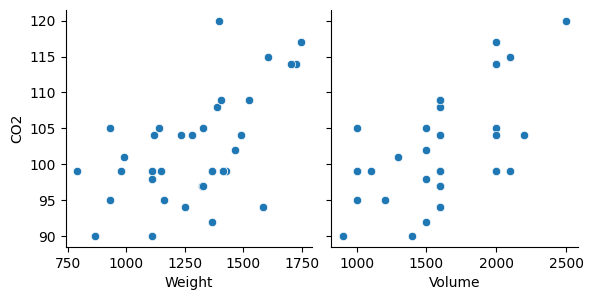

In [25]:
sns.pairplot(df, x_vars=['Weight', 'Volume'], y_vars='CO2', height=3, aspect=1, kind='scatter')
plt.show()

**SPLITTING DATASET INTO TRAINING AND TESTING SETS**

In [31]:
X = np.array(X)
y = np.array(y)
X = X.reshape(-1,2)
y = y.reshape(-1,1)

In [32]:
X[1:5]

array([[1160, 1200],
       [ 929, 1000],
       [ 865,  900],
       [1140, 1500]], dtype=int64)

In [29]:
y[1:5]

array([[ 95],
       [ 95],
       [ 90],
       [105]], dtype=int64)

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2)

**TRAIN A MULTI LINEAR REGRESSION MODEL**

In [60]:
from sklearn.linear_model import LinearRegression

MultiLinearRegression = LinearRegression(fit_intercept = True)
MultiLinearRegression.fit(X_train, y_train)

LinearRegression()

In [61]:
print('Linear Model Coeff(m)', MultiLinearRegression.coef_)
print('Linear Model Coeff(b)', MultiLinearRegression.intercept_)

Linear Model Coeff(m) [[0.00687649 0.00781748]]
Linear Model Coeff(b) [80.51903105]


**EVALUATE TRAINED MULTI LINEAR REGRESSION MODEL**

In [62]:
y_pred = MultiLinearRegression.predict(X_test) 
y_train= MultiLinearRegression.predict(X_train) 

In [63]:
comparison_df = pd.DataFrame({
    'Actual Values': y_test.flatten(),
    'Predicted Values': y_pred.flatten()
})
print(comparison_df)

   Actual Values  Predicted Values
0            101         97.489491
1            108        102.585335
2             97        102.145239
3            102        102.319323
4            104        106.399978
5             90         93.502935
6            109        102.688482
7             95         97.876747
